In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from functools import reduce
import inspect


from boostedhh import utils, hh_vars



In [2]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2

def print_directory_tree(base_dir, indent=""):
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(base_dir, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}|-- {os.path.basename(root)}/")
        sub_indent = " " * 4 * (level + 1)
        for file in files:
            print(f"{sub_indent}|-- {file}")

In [3]:
MAIN_DIR = Path("../../../")

plot_dir = MAIN_DIR / "plots/TriggerStudy/24Nov9"
plot_dir.mkdir(parents=True, exist_ok=True)

samples_tag = "25Feb7NoFatJetSel_v12_private_signal"
# samples_tag = "24Nov9UpdateTriggers_v12_private_signal"
base_dir = f"/eos/uscms/store/user/rkansal/bbtautau/skimmer/{samples_tag}/2022/"
# print_directory_tree(base_dir)

In [4]:
!ls /eos/uscms/store/user/rkansal/bbtautau/skimmer/25Feb7NoFatJetSel_v12_private_signal/2022/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet

out_0.parquet  out_2.parquet  out_4.parquet
out_1.parquet  out_3.parquet  out_5.parquet


In [5]:
df = pd.read_parquet(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/"
)    

In [6]:
df.head()

GenHiggsEta           GenHiggsPhi           GenHiggsMass        GenHiggsPt  \
            0         1           0         1            0      1          0   
0   -2.320312 -1.203125   -0.259766  1.003906        125.0  125.0      68.75   
1   -0.232910  0.634766   -1.300781  1.765625        125.0  125.0     138.00   
2   -0.146484 -0.285156   -2.015625  0.851562        125.0  125.0     225.00   
3   -0.521484  0.392578   -0.851562  2.039062        125.0  125.0     118.75   
4   -1.113281 -0.611328   -0.083496  2.937500        125.0  125.0     333.00   

           GenHiggsChildren      ... ak4JetMatchedGenJetPt             \
         1                0   1  ...                     0          1   
0   40.375                5  15  ...             70.524094  70.473900   
1  126.750               15   5  ...             65.868233  61.152817   
2  169.000               15   5  ...            111.413147  87.582359   
3  120.500                5  15  ...            121.680634  78.001244   
4  331.000               15   5  ...            255.448425  55.414589   

                               weight single_weight_genweight  \
            2             3         0                       0   
0   63.408207     37.935600  0.934380                 0.65807   
1   57.869720 -99999.000000  1.035074                 0.65807   
2  105.870567     48.408783 -1.048243                -0.65807   
3   37.800751     23.528605  0.122868                 0.65807   
4   43.649437     22.225801  0.130059                 0.65807   

  single_weight_pileup single_weight_ISRPartonShower  \
                     0                             0   
0            28.212471                     19.869631   
1            31.252803                     19.869631   
2            31.650413                     19.869631   
3             3.709844                     19.869631   
4             3.926960                     19.869631   

  single_weight_FSRPartonShower weight_noxsec  
                              0             0  
0                     19.869631      0.047026  
1                     19.869631      0.052093  
2                     19.869631     -0.052756  
3                     19.869631      0.006184  
4                     19.869631      0.006546  

[5 rows x 212 columns]

In [7]:
print(df.attrs)

{}


In [8]:
base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/"

'/eos/uscms/store/user/rkansal/bbtautau/skimmer/25Feb7NoFatJetSel_v12_private_signal/2022/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/'

In [9]:
!ls '/eos/uscms/store/user/rkansal/bbtautau/skimmer/25Feb7NoFatJetSel_v12_private_signal/2022/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/'


out_0.parquet  out_2.parquet  out_4.parquet
out_1.parquet  out_3.parquet  out_5.parquet


In [10]:
cf = utils.get_cutflow(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/pickles",
    "2022",
    "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8",
)

nEvents = len(df)

In [11]:
# list(df.columns)

In [12]:
weights = df["weight"][0]
H1_Pt = df[('GenHiggsPt', 0)].to_numpy()
H2_Pt = df[('GenHiggsPt', 1)].to_numpy()
H1_children = df[('GenHiggsChildren', 0)].to_numpy()
H2_children = df[('GenHiggsChildren', 1)].to_numpy()

deltaR_threshold = 1.2


deltaR_bb = np.sqrt((df[('GenbbEta', 0)] - df[('GenbbEta', 1)])**2 +
                     (df[('GenbbPhi', 0)] - df[('GenbbPhi', 1)])**2)

deltaR_tau = np.sqrt((df[('GenTauEta', 0)] - df[('GenTauEta', 1)])**2 +
                      (df[('GenTauPhi', 0)] - df[('GenTauPhi', 1)])**2)


bb_boosted, bb_resolved = deltaR_bb < deltaR_threshold, deltaR_bb >= deltaR_threshold
tau_boosted, tau_resolved = deltaR_tau < deltaR_threshold, deltaR_tau >= deltaR_threshold


In [13]:
N_gen = weights.sum()  # Sum of event weights
N_boosted_bb_boosted_tau = weights[bb_boosted & tau_boosted].sum()
N_boosted_bb_resolved_tau = weights[bb_boosted & tau_resolved].sum()
N_resolved_bb_boosted_tau = weights[bb_resolved & tau_boosted].sum()
N_resolved_bb_resolved_tau = weights[bb_resolved & tau_resolved].sum()

epsilon_boosted_bb_boosted_tau = N_boosted_bb_boosted_tau / N_gen
epsilon_boosted_bb_resolved_tau = N_boosted_bb_resolved_tau / N_gen
epsilon_resolved_bb_boosted_tau = N_resolved_bb_boosted_tau / N_gen
epsilon_resolved_bb_resolved_tau = N_resolved_bb_resolved_tau / N_gen

BR = 7.3/100 # Branching ratio HH->bbtautau
sigma_HH = 34 * BR  # HH cross-section in fb
L_run3 = 34.65 # 2022  # Expected luminosity in fb^-1
# Multiply by the BR

yield_boosted_bb_boosted_tau = sigma_HH * L_run3 * epsilon_boosted_bb_boosted_tau
yield_boosted_bb_resolved_tau = sigma_HH * L_run3 * epsilon_boosted_bb_resolved_tau
yield_resolved_bb_boosted_tau = sigma_HH * L_run3 * epsilon_resolved_bb_boosted_tau
yield_resolved_bb_resolved_tau = sigma_HH * L_run3 * epsilon_resolved_bb_resolved_tau

print(f"Expected Signal Yield (Boosted(bb) Boosted(ττ)): {yield_boosted_bb_boosted_tau:.3f}")
print(f"Expected Signal Yield (Boosted(bb) Resolved(ττ)): {yield_boosted_bb_resolved_tau:.3f}")
print(f"Expected Signal Yield (Resolved(bb) Boosted(ττ)): {yield_resolved_bb_boosted_tau:.3f}")
print(f"Expected Signal Yield (Resolved(bb) Resolved(ττ)): {yield_resolved_bb_resolved_tau:.3f}")

Expected Signal Yield (Boosted(bb) Boosted(ττ)): 4.864
Expected Signal Yield (Boosted(bb) Resolved(ττ)): 6.688
Expected Signal Yield (Resolved(bb) Boosted(ττ)): 6.546
Expected Signal Yield (Resolved(bb) Resolved(ττ)): 67.903


In [14]:

# Check the vector library

# pull the columns out in numpy (way easier!!)
# TODO: Clean it up later with just pd implemenation 
H_eta  = df[('GenHiggsEta', 0)].to_numpy(), df[('GenHiggsEta', 1)].to_numpy()
H_phi  = df[('GenHiggsPhi', 0)].to_numpy(), df[('GenHiggsPhi', 1)].to_numpy()
H_pt   = df[('GenHiggsPt',  0)].to_numpy(), df[('GenHiggsPt',  1)].to_numpy()
H_ch   = df[('GenHiggsChildren', 0)].to_numpy(), df[('GenHiggsChildren', 1)].to_numpy()

# Three AK8 jets
ak8_eta = np.vstack([df[('ak8FatJetEta', i)].to_numpy()
                     for i in (0,1,2)]).T       # shape (N,3)
ak8_phi = np.vstack([df[('ak8FatJetPhi', i)].to_numpy()
                     for i in (0,1,2)]).T
ak8_pt  = np.vstack([df[('ak8FatJetPt',  i)].to_numpy()
                     for i in (0,1,2)]).T

# Four AK4 jets
ak4_eta = np.vstack([df[('ak4JetEta',    i)].to_numpy()
                     for i in (0,1,2,3)]).T     # shape (N,4)
ak4_phi = np.vstack([df[('ak4JetPhi',    i)].to_numpy()
                     for i in (0,1,2,3)]).T
ak4_pt  = np.vstack([df[('ak4JetPt',     i)].to_numpy()
                     for i in (0,1,2,3)]).T

# replace NaNs (empty jet slots) with random values so they never match
ak8_eta  = np.nan_to_num(ak8_eta,  nan= 99.)
ak8_phi  = np.nan_to_num(ak8_phi,  nan= 99.)
ak8_pt   = np.nan_to_num(ak8_pt,   nan= -1.)
ak4_eta  = np.nan_to_num(ak4_eta,  nan= 99.)
ak4_phi  = np.nan_to_num(ak4_phi,  nan= 99.)
ak4_pt   = np.nan_to_num(ak4_pt,   nan= -1.)

tau_vec = utils.make_vector(df, name='GenTau')
tau_eta = tau_vec.eta  # shape (N, 2) 
tau_phi = tau_vec.phi

b_vec = utils.make_vector(df, name='Genbb')
b_eta = b_vec.eta  # shape (N, 2) 
b_phi = b_vec.phi

In [15]:
PN_b_th = 0.8

ak8_tagged_bb = df['ak8FatJetPNetXbbLegacy'].to_numpy()
mask = ak8_tagged_bb > PN_b_th
ak8_tagged_bb = ak8_tagged_bb[mask]

In [16]:
def delta_r(eta1, phi1, eta2, phi2):
    """Delta_R with stable, wrapped Delta_phi."""
    dphi = np.mod(phi1 - phi2 + np.pi, 2*np.pi) - np.pi # making \phi \in [-pi, +pi]
    return np.hypot(eta1 - eta2, dphi)

def match_jets_to_obj(jets_eta, jets_phi, jets_pt, obj_eta, obj_phi, dr_max, pt_min):
    """
    Returns
    -------
    match_mask : (N, J, O) boolean
        True if jet j in event n matches object o.
    """

    # jets_* = (N, J) 
    # obj_*  = (N, O)
    # jests_*[..., None] = (N, J, 1) 
    # obj_*[:,  None, :]  = (N, 1, O)
    # compute Delta R between each jet and each object (per event)
    
    dR = delta_r(jets_eta[..., None], jets_phi[..., None],
                 obj_eta[:,  None, :], obj_phi[:,  None, :])
    cond = (dR < dr_max) & (jets_pt[..., None] > pt_min) #  (N, J, O)
    return cond #  (N, J, O)

In [20]:

#################################
# ----- Truth level pass --------
#################################

gen_boosted_pass = bb_boosted & tau_boosted
gen_semi_pass = bb_boosted & tau_resolved


In [24]:
#################################
# ----- Recon level pass --------
#################################
dr_ak8, dr_ak4 = 0.8, 0.4
pt8_min, pt4_min = 200., 20.

b_ak8_mask = match_jets_to_obj(ak8_eta, ak8_phi, ak8_pt, b_eta, b_phi, dr_ak8, pt8_min)
tau_ak8_mask = match_jets_to_obj(ak8_eta, ak8_phi, ak8_pt, tau_eta, tau_phi, dr_ak8, pt8_min)
tau_ak4_mask = match_jets_to_obj(ak4_eta, ak4_phi, ak4_pt, tau_eta, tau_phi, dr_ak4, pt4_min)

# For each jet: does it contain BOTH b’s?
both_b_in_jet = b_ak8_mask.all(axis=2)      # (N, 3)
boosted_bb_pass = both_b_in_jet.any(axis=1) # (N,) True if both b are matched to the same ak8 jet

both_tau_in_jet = tau_ak8_mask.all(axis=2)  
boosted_tautau_pass =  both_tau_in_jet.any(axis=1)

both_tau_are_ak4 = tau_ak4_mask.any(axis=1)  # (N, 2)
is_2tautauak4 = both_tau_are_ak4.all(axis=1) # (N,)

# BOOSTED: 
#           1. Two b jets matched to the same ak8
#           2. Two tau jets matched to the same ak8

boosted_pass = boosted_bb_pass & boosted_tautau_pass & gen_boosted_pass

# SEMI‑RESOLVED:
#           1. Two b jets matched to the same ak8
#           2. Two tau jets matched to two different ak4 jets

semi_pass = boosted_bb_pass & is_2tautauak4 & gen_semi_pass


In [25]:
tau_ak4_mask.any(axis=1)

array([[ True,  True],
       [False,  True],
       [ True, False],
       ...,
       [False,  True],
       [ True,  True],
       [False,  True]])

In [26]:
recon_truth_dict = {
    'boosted' : (boosted_pass, gen_boosted_pass),
    'semi'    : (semi_pass, gen_semi_pass)
}

labels = {
    'boosted': 'Boosted',
    'semi': 'Semi-resolved'
}

In [27]:
'''
The track reconstruction efficiency is then defined as the ratio
of the number of signal truth particles matched to reconstructed 
tracks divided by the number of signal truth particles. 
'''

def efficiency_vs(var, masks, bins, weights=None):
    reco_mask, truth_mask = masks
    if weights is None:
        weights = np.ones_like(var)
    
    
    passed_reco_mask = reco_mask #& truth_mask

    total_truth, _   = np.histogram(var[truth_mask], bins=bins, weights=weights[truth_mask])
    total_recon, _   = np.histogram(var[passed_reco_mask], bins=bins, weights=weights[passed_reco_mask])
    with np.errstate(divide='ignore', invalid='ignore'):
        eff = total_recon / total_truth
    eff[total_truth == 0] = np.nan
    return eff, total_truth, total_recon


NameError: name 'xlabels_cfg' is not defined

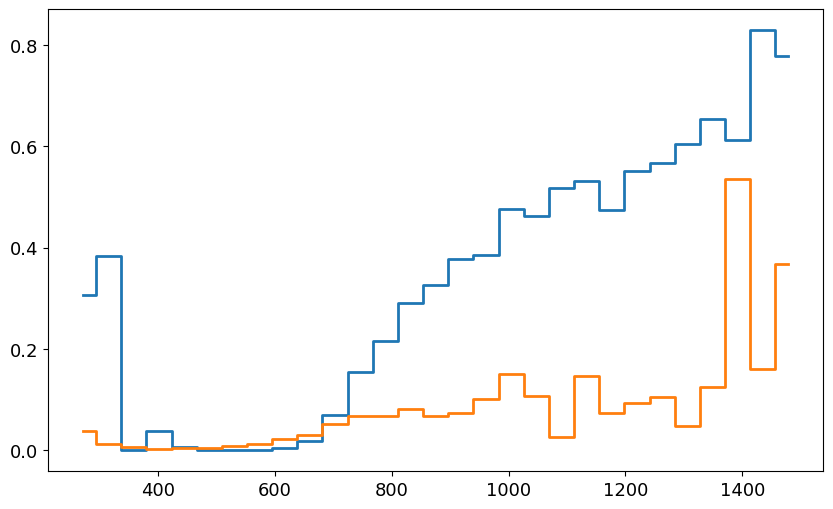

In [ ]:
# (VOI) Variables Of Interest
weights = df["weight"][0]
higgs = utils.make_vector(df, name="GenHiggs")
mhh = (higgs[:, 0] + higgs[:, 1]).mass
hbbpt = higgs[df["GenHiggsChildren"] == 5].pt
httpt = higgs[df["GenHiggsChildren"] == 15].pt

plt.rcParams.update({'font.size':13})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
]

for kinvar, kinname, kinlabel, bins in plot_vars:
    eff_boost, tot, pas = efficiency_vs(kinvar, recon_truth_dict['boosted'], bins, weights)
    eff_semi , _,   _   = efficiency_vs(kinvar, recon_truth_dict['semi'], bins, weights)
    bc        = .5*(bins[1:]+bins[:-1])      

    # Add weights in the histograms
    fig,ax = plt.subplots(figsize=(10,6))
    ax.step(bc,eff_boost,where='mid',lw=2,
            label='boosted') 
    ax.step(bc,eff_semi   ,where='mid',lw=2,
            label='semi-resolved')
    ax.set(xlabel=kinlabel + r' [$GeV]$',ylabel='Recon-Efficiency',
           ylim=(0,1.2))

    ax.axhline(y=1, linestyle=':', color='black',
           alpha=0.7, linewidth=2)


    ax.grid(ls='-.',alpha=.5)

    ax2 = ax.twinx()
    ax2.bar(bc,tot,width=np.diff(bins),alpha=.15,
            label=kinlabel + ' Distribution')
    ax2.set_ylabel('Counts') # May be add weights in here

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    


In [ ]:
assert 1 = 2

In [ ]:
for tag, (reco_mask, truth_mask) in recon_truth_dict.items():
    for name, arr in zip(('mhh','hbbpt','httpt'), (mhh,hbbpt,httpt)):
        eff, tot, pas = efficiency_vs(arr, (reco_mask, truth_mask),
                                bin_cfg[name], weights=weights)

        results[f"{name}_{tag}"] = {
            'bins': bin_cfg[name],
            'eff': eff,
            'total': tot,
            'passed': pas,
        }




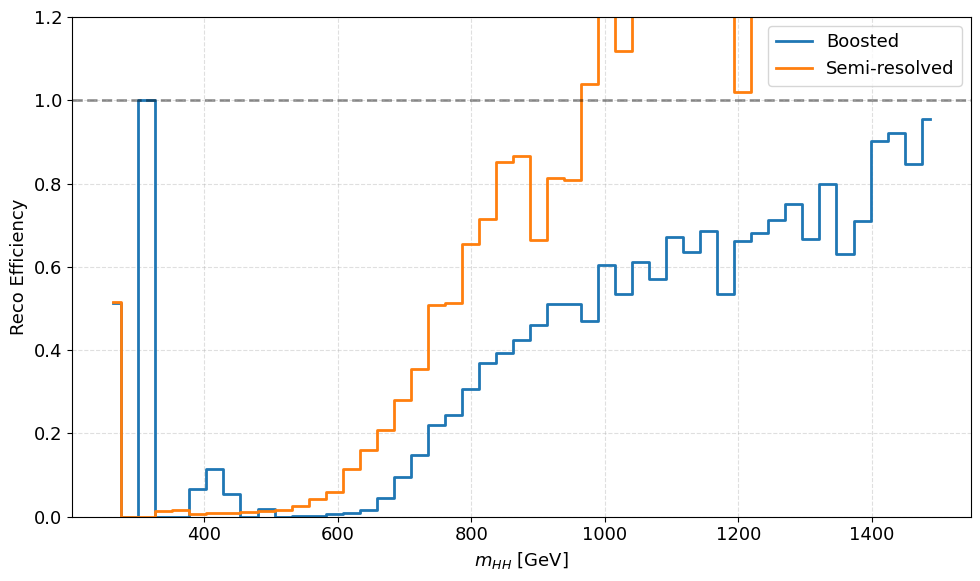

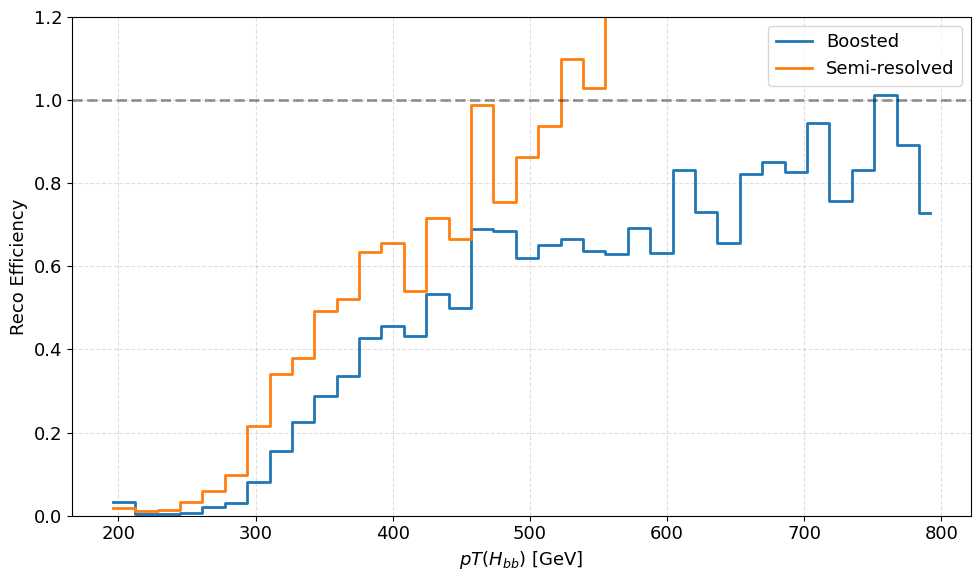

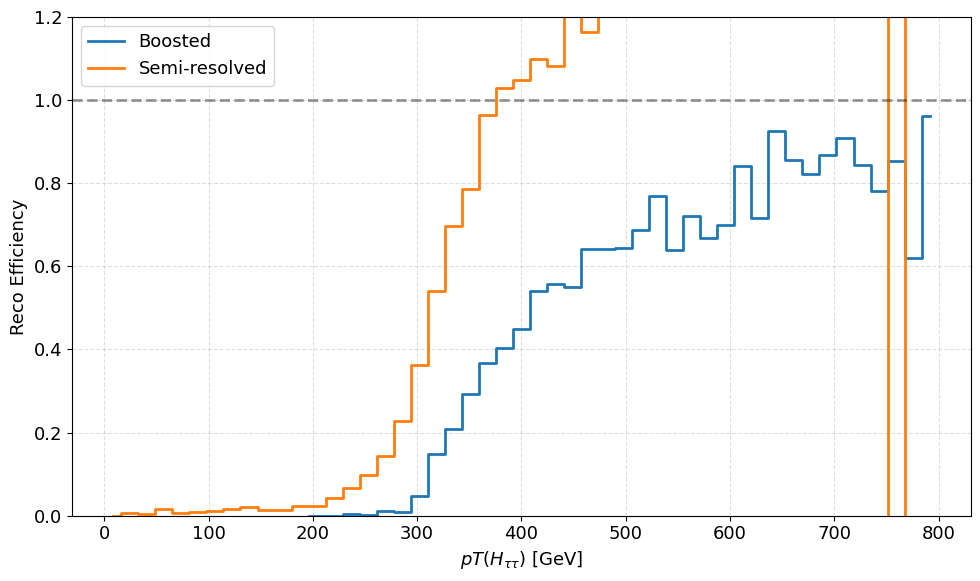

In [ ]:

for vname in ('mhh', 'hbbpt', 'httpt'):
    fig, ax = plt.subplots(figsize=(10,6))
    ax.set(xlabel=xlabels_cfg[vname] + ' [GeV]', ylabel='Reco Efficiency', ylim=(0,1.2))

    for tag in recon_truth_dict:
        res = results[f"{vname}_{tag}"]
        bins = res['bins']
        bc = 0.5 * (bins[1:] + bins[:-1])
        ax.step(bc, res['eff'], where='mid', lw=2, label=labels[tag])
    
    ax.axhline(y=1, linestyle='--', color='black', alpha=0.4, linewidth=2)
    ax.grid(ls='--', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# print(b_ak8_mask.shape)
# print(b_ak8_mask[0]) #tau_ak4_mask[0]
# print(b_ak8_mask[0].any(axis=1))
# print(b_ak8_mask[0].any(axis=0))

# print(b_ak8_mask.any(axis=2)[0])
# print(b_ak8_mask.any(axis=1)[0])
# print(b_ak8_mask.any(axis=1).all(axis=1))
# print(np.sum(b_ak8_mask.any(axis=1).all(axis=1)))
# display(b_ak8_mask[70])

In [ ]:
tau_ak4_mask = match_jets_to_obj(ak4_eta, ak4_phi, ak4_pt, tau_eta, tau_phi, 0.4, 20)
is_2tautauak4 = tau_ak4_mask.any(axis=1).all(axis=1)

In [ ]:
# display(tau_ak4_mask.shape)
# display(tau_ak4_mask[0]) #tau_ak4_mask[0]
# display(tau_ak4_mask[0].any(axis=1))
# display(tau_ak4_mask[0].any(axis=0))

# display(tau_ak4_mask.any(axis=2)[0])
# display(tau_ak4_mask.any(axis=1)[0])
# display(tau_ak4_mask.any(axis=1).all(axis=1))

In [ ]:
(boosted_tautau_pass & is_2tautauak4).sum() # This is strange...ask raghav

8682

In [ ]:
dr_ak8, dr_ak4 = 0.8, 0.4
pt8_min, pt4_min = 200., 20.

# 1. BOOSTED: We need two distinct AK8 jets, one per Higgs
match0 = match_mask(H_eta[0], H_phi[0],
                    ak8_eta, ak8_phi, ak8_pt,
                    dr_ak8, pt8_min, 1)
match1 = match_mask(H_eta[1], H_phi[1],
                    ak8_eta, ak8_phi, ak8_pt,
                    dr_ak8, pt8_min, 1)
boosted_pass = match0 & match1      # boolean (N,)

# 2. SEMI‑RESOLVED:
# Whch Higgs is bb (child == 5) and TauTau (15)
is_bb   = (np.vstack(H_ch) == 5).T  # shape (N,2) bool
is_tau  = (np.vstack(H_ch) == 15).T 
bbIdx   = is_bb.argmax(axis=1)      # 0/1
tauIdx  = is_tau.argmax(axis=1)

#  AK8 for bb‑Higgs
bb_ak8  = ( (bbIdx==0) & match0 ) | ( (bbIdx==1) & match1)

# >=2 AK4 for TauTau‑Higgs


tau_ak4_mask = match_jets_to_obj(ak4_eta, ak4_phi, ak4_pt, tau_eta, tau_phi, 0.4, 20)
is_2tautau_ak4 = tau_ak4_mask.any(axis=1).all(axis=1)

semi_pass = bb_ak8 & is_2tautau_ak4       # boolean (N,)


In [ ]:
# efficiency vs variable 
def efficiency_vs(var, sel_mask, bins):
    counts_total, _   = np.histogram(var, bins=bins)
    counts_pass,  _   = np.histogram(var[sel_mask], bins=bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        eff = counts_pass / counts_total
    eff[counts_total == 0] = np.nan
    return eff, counts_total, counts_pass


In [ ]:
# (VOI) Variables Of Interest
mhh   = (utils.make_vector(df, name='GenHiggs')[:,0] +
         utils.make_vector(df, name='GenHiggs')[:,1]).mass
hbbpt = np.where(bbIdx==0, H_pt[0], H_pt[1])   # pT of Hbb
httpt = np.where(tauIdx==0, H_pt[0], H_pt[1])  # pT of Htt

bin_cfg = {
    'mhh'   : np.linspace(250,1500,50),
    'hbbpt' : np.linspace(0,800,50),
    'httpt' : np.linspace(0,800,50),
}

xlabels_cfg = {
    'mhh'   : r'$m_{HH}$',
    'hbbpt' : r'$pT (H_{bb})$',
    'httpt' : r'$pT (H_{\tau\tau})$',
}

results = {}
for name, arr in zip(('mhh','hbbpt','httpt'), (mhh,hbbpt,httpt)):
    eff_boost, tot, pas = efficiency_vs(arr, boosted_pass, bin_cfg[name])
    eff_semi , _,   _   = efficiency_vs(arr, semi_pass, bin_cfg[name])
    results[name] = dict(
        bins = bin_cfg[name],
        eff_boosted = eff_boost,
        eff_semi    = eff_semi,
        total       = tot,
    )


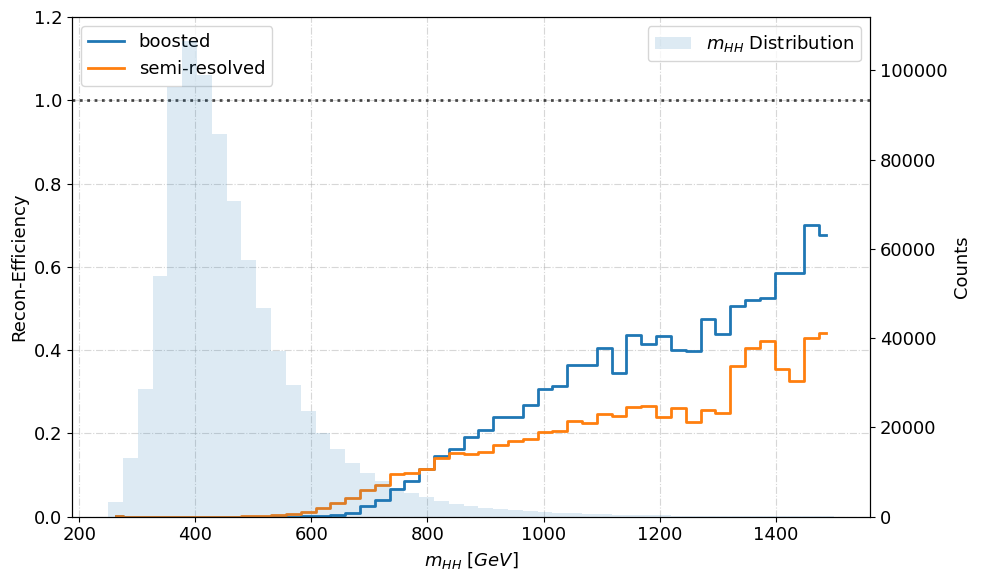

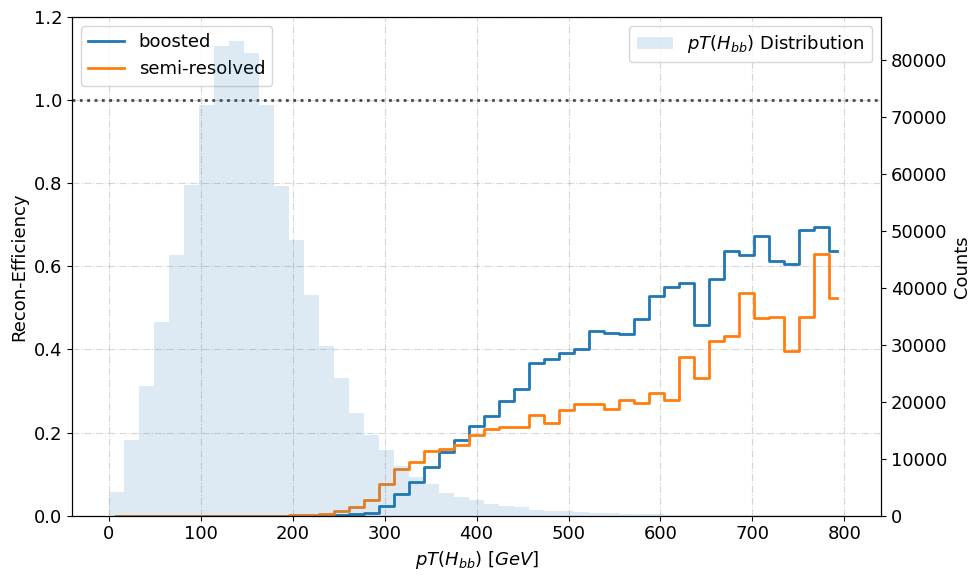

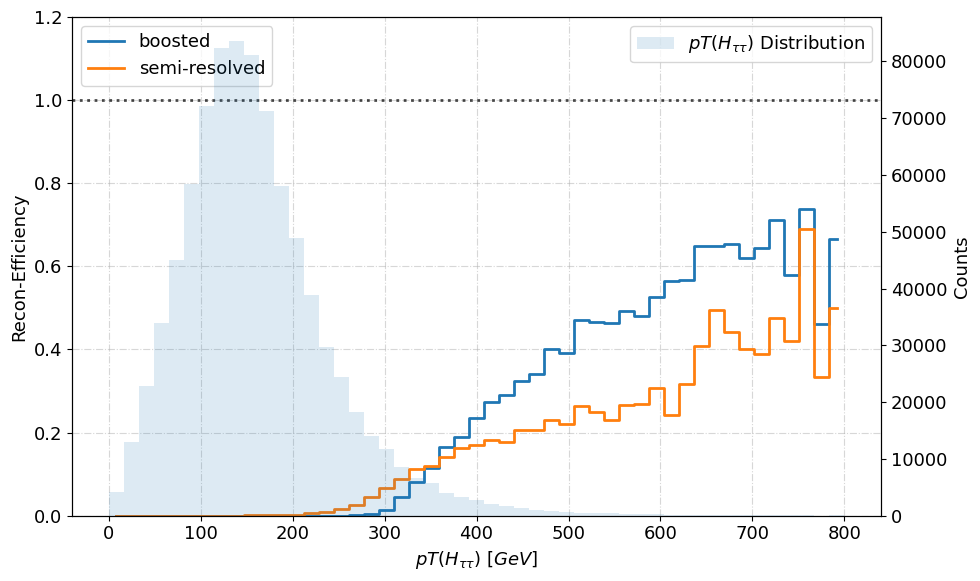

KeyError: 'eff_boosted'

In [ ]:
plt.rcParams.update({'font.size':13})

for vname,res in results.items():
    bins      = res['bins']
    bc        = .5*(bins[1:]+bins[:-1])      
    e_boosted = res['eff_boosted']
    e_semi    = res['eff_semi']
    tot       = res['total']

    # Add weights in the histograms
    fig,ax = plt.subplots(figsize=(10,6))
    ax.step(bc,e_boosted,where='mid',lw=2,
            label='boosted') 
    ax.step(bc,e_semi   ,where='mid',lw=2,
            label='semi‑resolved')
    ax.set(xlabel=xlabels_cfg[vname] + r' [$GeV]$',ylabel='Recon-Efficiency',
           ylim=(0,1.2))

    ax.axhline(y=1, linestyle=':', color='black',
           alpha=0.7, linewidth=2)


    ax.grid(ls='-.',alpha=.5)

    ax2 = ax.twinx()
    ax2.bar(bc,tot,width=np.diff(bins),alpha=.15,
            label=xlabels_cfg[vname] + ' Distribution')
    ax2.set_ylabel('Counts') # May be add weights in here

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    
